Train size : 248  (83 terminated)
Test size  : 63  (21 terminated)

── Cross-validation (5-fold) ──────────────────────────────
  Accuracy : 0.637 ± 0.059
  F1       : 0.534 ± 0.071

── Test set results ───────────────────────────────────────
                precision    recall  f1-score   support

    Active (0)       0.81      0.69      0.74        42
Terminated (1)       0.52      0.67      0.58        21

      accuracy                           0.68        63
     macro avg       0.66      0.68      0.66        63
  weighted avg       0.71      0.68      0.69        63



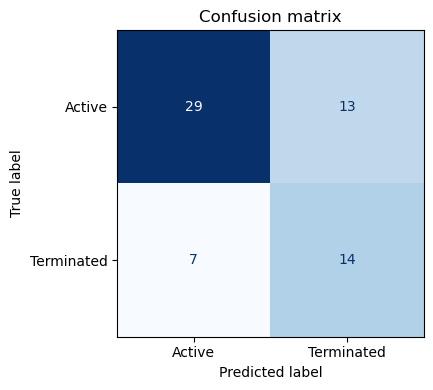

Plot saved → baseline_results.png

── Top 10 most influential features ──────────────────────
RecruitmentSource_Website             -0.508600
RecruitmentSource_Employee Referral   -0.476539
RecruitmentSource_Indeed              -0.473430
RecruitmentSource_LinkedIn            -0.470766
DaysLateLast30                         0.365748
RecruitmentSource_Other               -0.352687
ManagerID                              0.345238
MarriedID                              0.332430
Salary                                 0.290199
SpecialProjectsCount                  -0.284287


In [131]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# ── Load cleaned data ─────────────────────────────────────────────────────────
df = pd.read_csv("hr_cleaned.csv")
X = df.drop(columns=["Termd"])
y = df["Termd"]

# ── Train / Test split (stratified to preserve 2:1 ratio) ────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size : {X_train.shape[0]}  ({y_train.sum()} terminated)")
print(f"Test size  : {X_test.shape[0]}  ({y_test.sum()} terminated)\n")

# ── Pipeline: scale → logistic regression ────────────────────────────────────
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

# ── Cross-validation (5-fold stratified) ─────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    pipeline, X_train, y_train, cv=cv,
    scoring=["accuracy", "f1"],
    return_train_score=False
)

print("── Cross-validation (5-fold) ──────────────────────────────")
print(f"  Accuracy : {cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}")
print(f"  F1       : {cv_results['test_f1'].mean():.3f} ± {cv_results['test_f1'].std():.3f}\n")

# ── Final fit on full train set → evaluate on test set ───────────────────────
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("── Test set results ───────────────────────────────────────")
print(classification_report(y_test, y_pred, target_names=["Active (0)", "Terminated (1)"]))

# ── Plot: confusion matrix only ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["Active", "Terminated"]
).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion matrix")
plt.tight_layout()
plt.savefig("baseline_results.png", dpi=150)
plt.show()
print("Plot saved → baseline_results.png")

# ── Top feature coefficients avec coef_ ──────────────────────────────────────────────────
coefs = pd.Series(
    pipeline.named_steps["clf"].coef_[0],
    index=X.columns
).sort_values(key=abs, ascending=False)

print("\n── Top 10 most influential features ──────────────────────")
print(coefs.head(10).to_string())

scale_pos_weight = 1.99  (165 active / 83 terminated)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


C:\Users\othma\miniconda3\envs\torch311\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:29:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best params : {'subsample': 1.0, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.6}
Best CV AUC : 0.657

── Test set results ───────────────────────────────────────
                precision    recall  f1-score   support

    Active (0)       0.77      0.79      0.78        42
Terminated (1)       0.55      0.52      0.54        21

      accuracy                           0.70        63
     macro avg       0.66      0.65      0.66        63
  weighted avg       0.69      0.70      0.70        63

  ROC-AUC : 0.684

  Train AUC : 0.996
  Test  AUC : 0.684
  Gap       : 0.312  possible overfit



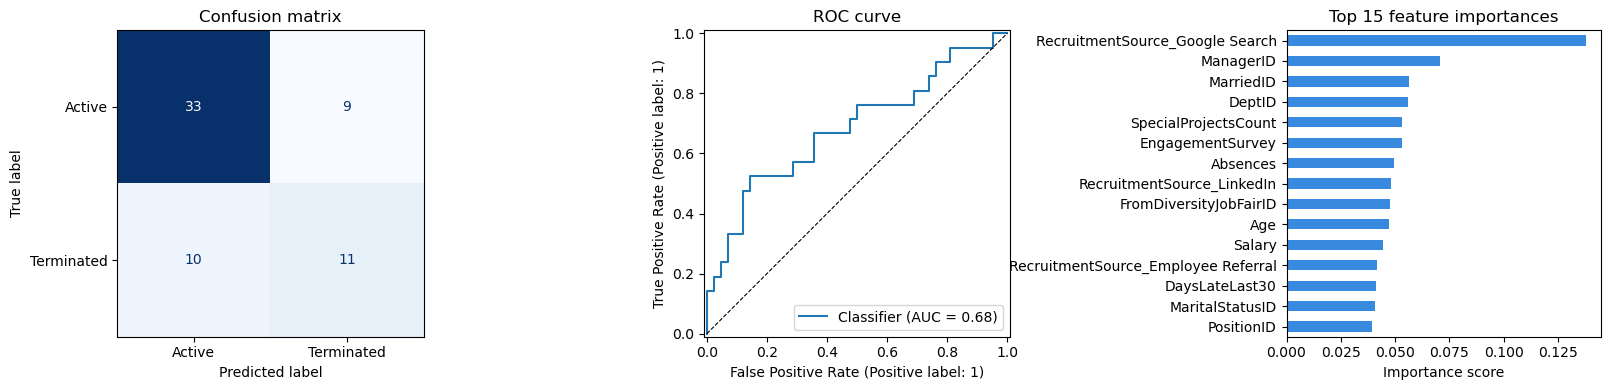

Plot saved → xgboost_results.png


In [132]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv("hr_cleaned.csv")



X = df.drop(columns=["Termd"])
y = df["Termd"]

# ── Train / Test split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Class imbalance ratio for scale_pos_weight ───────────────────────────────
# XGBoost handles imbalance via scale_pos_weight = count(0) / count(1)
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale = neg / pos
print(f"scale_pos_weight = {scale:.2f}  ({neg} active / {pos} terminated)\n")

# ── Hyperparameter search ─────────────────────────────────────────────────────
param_grid = {
    "n_estimators":      [100, 200, 300, 400],
    "max_depth":         [2, 3, 4, 5],
    "learning_rate":     [0.01, 0.05, 0.1, 0.2],
    "subsample":         [0.6, 0.8, 1.0],
    "colsample_bytree":  [0.6, 0.8, 1.0],
    "min_child_weight":  [1, 3, 5],
    "gamma":             [0, 0.1, 0.3],
}

xgb = XGBClassifier(
    scale_pos_weight=scale,
    eval_metric="auc",
    random_state=42,
    use_label_encoder=False
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=50,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print(f"\nBest params : {search.best_params_}")
print(f"Best CV AUC : {search.best_score_:.3f}\n")

# ── Evaluate best model on test set ──────────────────────────────────────────
best_model = search.best_estimator_
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("── Test set results ───────────────────────────────────────")
print(classification_report(y_test, y_pred, target_names=["Active (0)", "Terminated (1)"]))
print(f"  ROC-AUC : {roc_auc_score(y_test, y_proba):.3f}\n")

# ── Train vs Test AUC gap ─────────────────────────────────────────────────────
train_auc = roc_auc_score(y_train, best_model.predict_proba(X_train)[:, 1])
test_auc  = roc_auc_score(y_test, y_proba)
print(f"  Train AUC : {train_auc:.3f}")
print(f"  Test  AUC : {test_auc:.3f}")
print(f"  Gap       : {train_auc - test_auc:.3f}  {'possible overfit' if train_auc - test_auc > 0.05 else ' gap is small'}\n")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["Active", "Terminated"]
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion matrix")

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[1].set_title("ROC curve")

# Feature importance avec coef_
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True).tail(15)

importance.plot(kind="barh", ax=axes[2], color="#378ADD")
axes[2].set_title("Top 15 feature importances")
axes[2].set_xlabel("Importance score")

plt.tight_layout()
plt.savefig("xgboost_results.png", dpi=150)
plt.show()
print("Plot saved → xgboost_results.png")

Train size : 248  (83 terminated)
Test size  : 63  (21 terminated)

── Test set results ───────────────────────────────────────
                precision    recall  f1-score   support

    Active (0)       0.80      0.86      0.83        42
Terminated (1)       0.67      0.57      0.62        21

      accuracy                           0.76        63
     macro avg       0.73      0.71      0.72        63
  weighted avg       0.76      0.76      0.76        63

  ROC-AUC : 0.782

  Train AUC : 0.801
  Test  AUC : 0.782
  Gap       : 0.018   gap is small



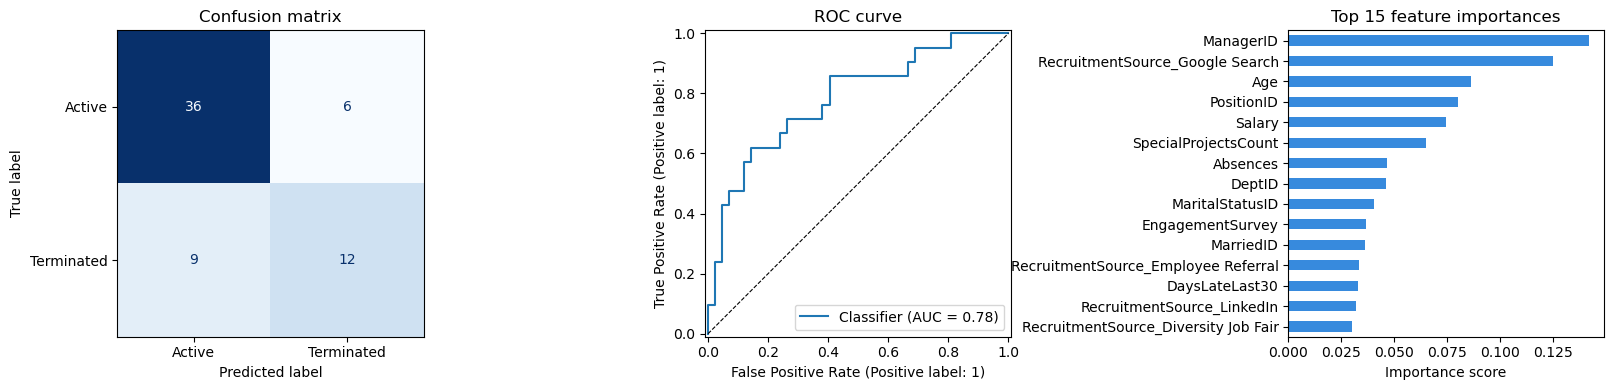

['random_forest_model.pkl']

In [141]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv("hr_cleaned.csv")

X = df.drop(columns=["Termd"])
y = df["Termd"]

# ── Train / Test split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape[0]}  ({y_train.sum()} terminated)")
print(f"Test size  : {X_test.shape[0]}  ({y_test.sum()} terminated)\n")

# ── Model ─────────────────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=2,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)

# ── Cross-validation ──────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    rf, X_train, y_train, cv=cv,
    scoring=["accuracy", "f1", "roc_auc"],
    return_train_score=False
)

# ── Final fit → test set ──────────────────────────────────────────────────────
rf.fit(X_train, y_train)
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("── Test set results ───────────────────────────────────────")
print(classification_report(y_test, y_pred, target_names=["Active (0)", "Terminated (1)"]))
print(f"  ROC-AUC : {roc_auc_score(y_test, y_proba):.3f}")

# ── Overfit check ─────────────────────────────────────────────────────────────
train_auc = roc_auc_score(y_train, rf.predict_proba(X_train)[:, 1])
test_auc  = roc_auc_score(y_test, y_proba)
print(f"\n  Train AUC : {train_auc:.3f}")
print(f"  Test  AUC : {test_auc:.3f}")
print(f"  Gap       : {train_auc - test_auc:.3f}  {' possible overfit' if train_auc - test_auc > 0.05 else ' gap is small'}\n")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["Active", "Terminated"]
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion matrix")

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[1].set_title("ROC curve")

# Feature importances en uutilisant le coef
importance = pd.Series(
    rf.feature_importances_, index=X.columns
).sort_values(ascending=True).tail(15)

importance.plot(kind="barh", ax=axes[2], color="#378ADD")
axes[2].set_title("Top 15 feature importances")
axes[2].set_xlabel("Importance score")

plt.tight_layout()
plt.savefig("rf_results.png", dpi=150)
plt.show()
import joblib
joblib.dump(rf, "random_forest_model.pkl")

In [145]:
import os
import time
import joblib
import pandas as pd
from codecarbon import EmissionsTracker

# Load model and data
model = joblib.load("random_forest_model.pkl")
df = pd.read_csv("hr_cleaned.csv")

X = df.drop(columns=["Termd"])

# ------------------------------------------------
# 1. Model size
# ------------------------------------------------
model_size_bytes = os.path.getsize("random_forest_model.pkl")
model_size_mb = model_size_bytes / (1024**2)

print(f"Model size: {model_size_mb:.3f} MB")

# ------------------------------------------------
# 2. Inference time
# ------------------------------------------------
start = time.time()
pred = model.predict(X)
end = time.time()

inference_time = end - start

print(f"Inference time (CPU): {inference_time:.6f} seconds for {len(X)} samples")
print(f"Inference time per sample: {inference_time/len(X):.8f} seconds")

# ------------------------------------------------
# 3. Energy consumption (CodeCarbon)
# ------------------------------------------------
tracker = EmissionsTracker()

tracker.start()

model.predict(X)

emissions = tracker.stop()

print(f"Estimated CO2 emissions: {emissions:.6f} kgCO2eq")

[codecarbon WARNING @ 10:10:35] Multiple instances of codecarbon are allowed to run at the same time.


Model size: 0.342 MB
Inference time (CPU): 0.024390 seconds for 311 samples
Inference time per sample: 0.00007842 seconds


[codecarbon INFO @ 10:10:37] [setup] RAM Tracking...
[codecarbon INFO @ 10:10:37] [setup] CPU Tracking...
[codecarbon WARNING @ 10:10:37] We saw that you have a 13th Gen Intel(R) Core(TM) i7-13650HX but we don't know it. Please contact us.
[codecarbon WARNING @ 10:10:37] We will use the default power consumption of 4 W per thread for your 20 CPU, so 80W.
[codecarbon WARNING @ 10:10:37] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 10:10:37] CPU Model on constant consumption mode: 13th Gen Intel(R) Core(TM) i7-13650HX
[codecarbon WARNING @ 10:10:37] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 10:10:37] [setup] GPU Tracking...
[codecarbon INFO @ 10:10:37] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 10:10:37] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
            

Estimated CO2 emissions: 0.000060 kgCO2eq


SHAP values shape : (63, 24)
Base value        : 0.4977

── Employee at index 2 ────────────────────────────────
  Predicted proba : 0.460 → Active
  Actual label    : Active



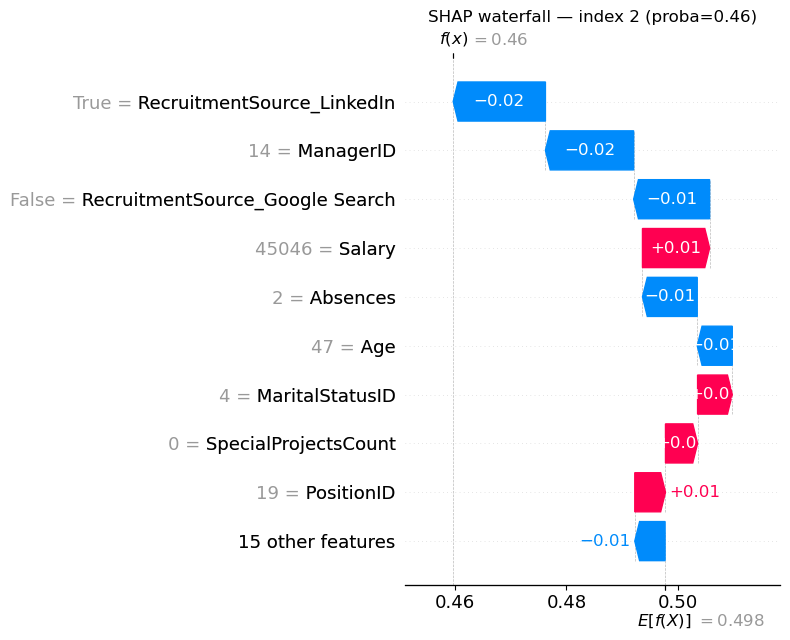

Saved → shap_employee_2.png


In [140]:
## import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import shap
import matplotlib.pyplot as plt

# ── Load + train 
df = pd.read_csv("hr_cleaned.csv")

X = df.drop(columns=["Termd"])
y = df["Termd"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=2,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)
rf.fit(X_train, y_train)

# ── SHAP explainer 
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Handle both old shap (list) and new shap (3D array)
if isinstance(shap_values, list):
    sv_terminated  = shap_values[1]          # old: list of [class_0, class_1]
    base_value     = explainer.expected_value[1]
else:
    sv_terminated  = shap_values[:, :, 1]    # new: (n_samples, n_features, n_classes)
    base_value     = explainer.expected_value[1]

print(f"SHAP values shape : {sv_terminated.shape}")
print(f"Base value        : {base_value:.4f}\n")

y_proba = rf.predict_proba(X_test)[:, 1]

# # ── 1. GLOBAL — Beeswarm 
# print("Generating global SHAP beeswarm plot...")
# plt.figure()
# shap.summary_plot(sv_terminated, X_test, plot_type="dot", show=False)
# plt.title("SHAP — global feature impact (Terminated class)")
# plt.tight_layout()
# plt.savefig("shap_global_beeswarm.png", dpi=150, bbox_inches="tight")
# plt.show()
# print("Saved → shap_global_beeswarm.png\n")

# # ── 2. GLOBAL — Bar ───────────────────────────────────────────────────────────
# print("Generating global SHAP bar plot...")
# plt.figure()
# shap.summary_plot(sv_terminated, X_test, plot_type="bar", show=False)
# plt.title("SHAP — mean feature importance (Terminated class)")
# plt.tight_layout()
# plt.savefig("shap_global_bar.png", dpi=150, bbox_inches="tight")
# plt.show()
# print("Saved → shap_global_bar.png\n")

# # ── 3. SINGLE — Waterfall (highest risk employee) ────────────────────────────
# highest_idx = np.argmax(y_proba)
# actual      = y_test.iloc[highest_idx]

# print(f"── Single prediction analysis ─────────────────────────────")
# print(f"  Sample index    : {highest_idx}")
# print(f"  Predicted proba : {y_proba[highest_idx]:.3f} → {'Terminated' if y_proba[highest_idx] >= 0.5 else 'Active'}")
# print(f"  Actual label    : {'Terminated' if actual == 1 else 'Active'}\n")

# explanation = shap.Explanation(
#     values        = sv_terminated[highest_idx],
#     base_values   = base_value,
#     data          = X_test.iloc[highest_idx].values,
#     feature_names = X_test.columns.tolist()
# )

# plt.figure()
# shap.plots.waterfall(explanation, show=False)
# plt.title(f"SHAP waterfall — sample {highest_idx} (proba={y_proba[highest_idx]:.2f})")
# plt.tight_layout()
# plt.savefig("shap_single_waterfall.png", dpi=150, bbox_inches="tight")
# plt.show()
# print("Saved → shap_single_waterfall.png\n")

# # ── 4. Force plot (HTML) ──────────────────────────────────────────────────────
# shap.initjs()
# force = shap.force_plot(
#     base_value,
#     sv_terminated[highest_idx],
#     X_test.iloc[highest_idx],
#     show=False
# )
# shap.save_html("shap_force_plot.html", force)
# print("Saved → shap_force_plot.html\n")

# ── 5. Explain any employee by index 
def explain_employee(idx):
    prob   = y_proba[idx]
    actual = y_test.iloc[idx]
    print(f"── Employee at index {idx} ────────────────────────────────")
    print(f"  Predicted proba : {prob:.3f} → {'Terminated' if prob >= 0.5 else 'Active'}")
    print(f"  Actual label    : {'Terminated' if actual == 1 else 'Active'}\n")

    exp = shap.Explanation(
        values        = sv_terminated[idx],
        base_values   = base_value,
        data          = X_test.iloc[idx].values,
        feature_names = X_test.columns.tolist()
    )
    plt.figure()
    shap.plots.waterfall(exp, show=False)
    plt.title(f"SHAP waterfall — index {idx} (proba={prob:.2f})")
    plt.tight_layout()
    plt.savefig(f"shap_employee_{idx}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → shap_employee_{idx}.png")


explain_employee(2)